# DESI QSO Simulations

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table, vstack, MaskedColumn
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *
from Simulation.fitMap import *
from Simulation.lumMag_sampling import *
from Simulation.mappers import DensityMapper, FracCovMapper

In [2]:
nside = 128
npix= hp.nside2npix(nside)
area_deg2 = hp.nside2pixarea(nside, degrees=True)
print("Number of pixels = {}".format(npix))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


## FRACCOV

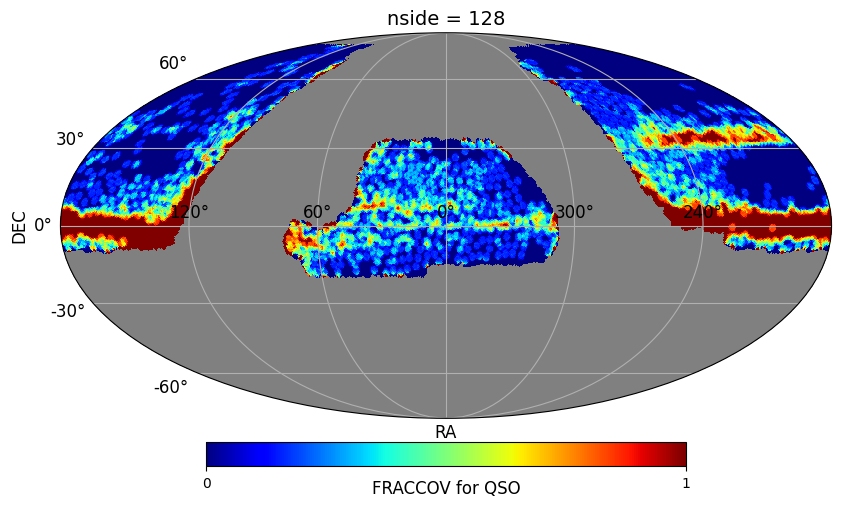

In [3]:
#File name:
DIR = "data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-dark.fits"

#Reading file:
DR1_Mapper = FracCovMapper.read(FILE_DR1, nest=True)
DR1_Mapper.get_nside(nside)
DR1_Mapper._set_suffixTextPlot(unit = "QSO") #to customize the unit of plots.
DR1_Mapper.plot(use_map = "nside", title = f"nside = {DR1_Mapper.nside}")

## Density

### From DESI data

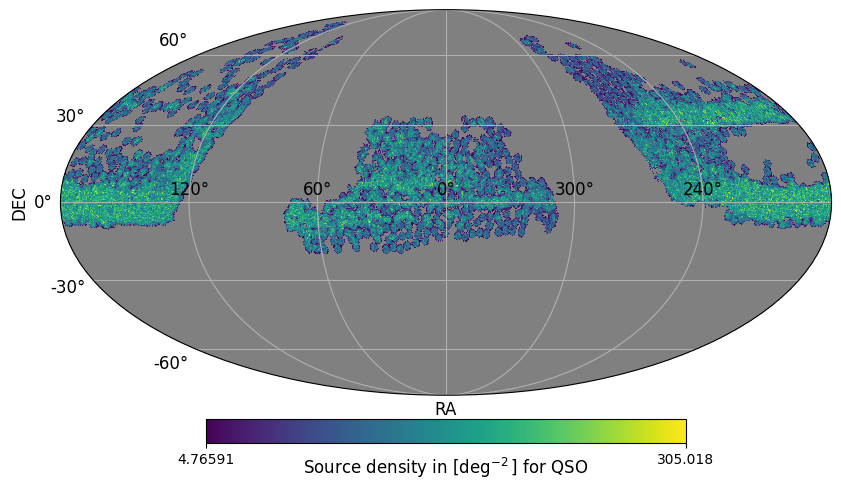

In [4]:
#File names:
FILE_NGC = DIR + "QSO_NGC_clustering.dat.fits"
FILE_SGC = DIR + "QSO_SGC_clustering.dat.fits"

#Reading files:
NGC_Mapper = DensityMapper.read(FILE_NGC, nside=nside, nest=True)
SGC_Mapper = DensityMapper.read(FILE_SGC, nside=nside, nest=True)
ALL_Mapper = NGC_Mapper.add(SGC_Mapper)
ALL_Mapper._set_suffixTextPlot(unit = "QSO") #to customize the unit of plots.
ALL_Mapper.set_mask()
ALL_Mapper.plot("Masked")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.492e+06 (χ²/ndof = 12.7) │              Nfcn = 406              │
│ EDM = 9.16e-07 (Goal: 0.0002)    │           time = 12.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │   79.93   │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 1 │ A    │  0.6125   │  0.0013   │  -0.0013   │   0.0013   │    0    │    1    │       │
│ 2 │ ra   │  186.22   │   0.24    │   -0.24    │    0.24    │    0    │   360   │       │
│ 3 │ dec  │  -70.06   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │  -0.0013  │  0.0013   │   -0.24   │   0.24    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │        M        A       ra      dec │
├─────┼─────────────────────────────────────┤
│   M │  0.00271  34.2e-6   0.0005  -0.0009 │
│   A │  34.2e-6 1.62e-06  39.1e-6 -18.6e-6 │
│  ra │   0.0005  39.1e-6   0.0571   -0.000 │
│ dec │  -0.0009 -18.6e-6   -0.000   0.0039 │
└─────┴─────────────────────────────────────┘

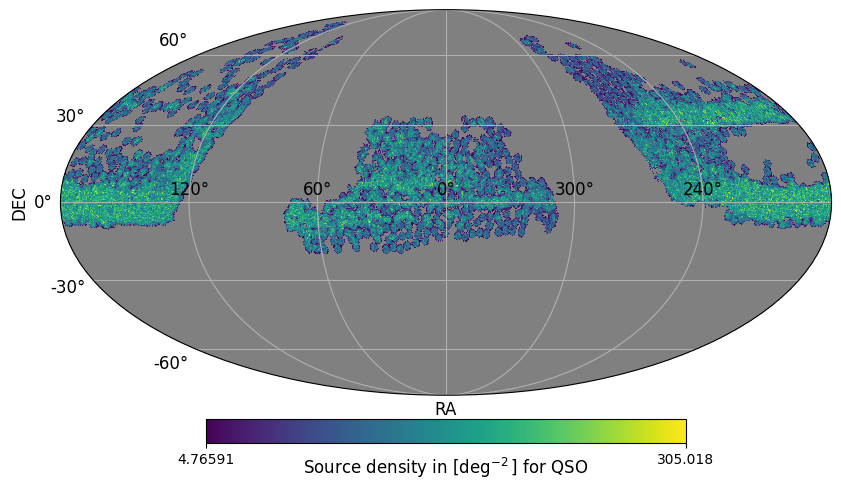

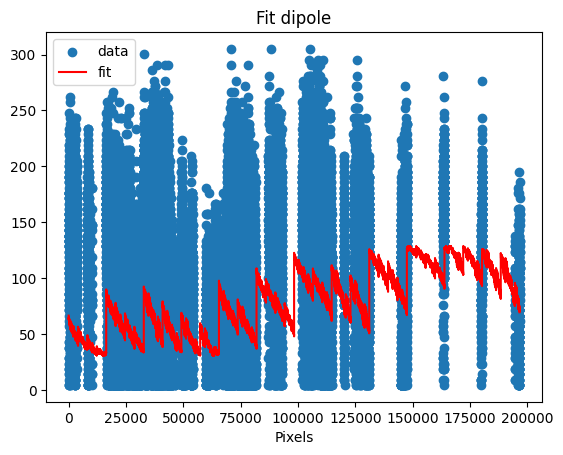

In [5]:
init =  (1000, 1, 100, 40)
m = ALL_Mapper.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.843e+05 (χ²/ndof = 4.0)  │              Nfcn = 774              │
│ EDM = 1.96e-05 (Goal: 0.0002)    │           time = 23.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  114.060  │   0.015   │   -0.015   │   0.015    │    0    │         │       │
│ 1 │ A    │ 404.65e-3 │  0.31e-3  │  -0.31e-3  │  0.31e-3   │    0    │    1    │       │
│ 2 │ ra   │  0.04e-3  │269289.05e-3│  -0.04e-3  │269289.05e-3│    0    │   360   │       │
│ 3 │ dec  │-89.99999999968│0.00463062461│-0.00000000032│0.00463062461│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.015   │   0.015   │ -0.31e-3  │  0.31e-3  │ -0.04e-3  │269289.05e-3│ -0.32e-9  │4630624.61e-9│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │               M               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│   M │        0.000216         0.08e-6        -0.01e-3           0e-12 │
│   A │         0.08e-6        9.64e-08      -387.64e-6           1e-12 │
│  ra │        -0.01e-3      -387.64e-6        2.44e+06 -3.819670420e-3 │
│ dec │           0e-12           1e-12 -3.819670420e-3        5.99e-12 │
└─────┴─────────────────────────────────────────────────────────────────┘

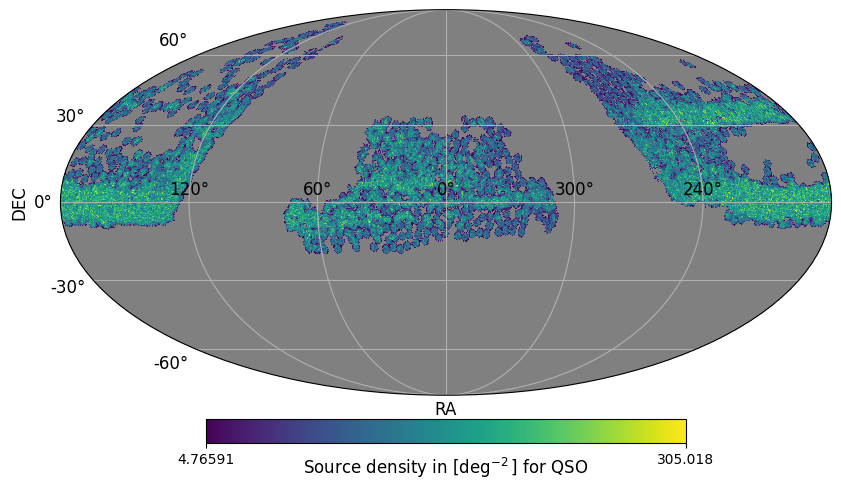

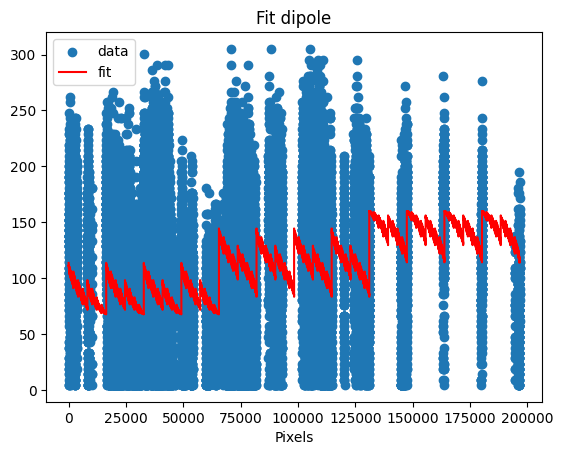

In [6]:
init =  (1000, 1, 100, 40)
m = ALL_Mapper.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From simulation

Total number of sources in the entire sky : 12386304
Theorical number of sources in one pixel : 63


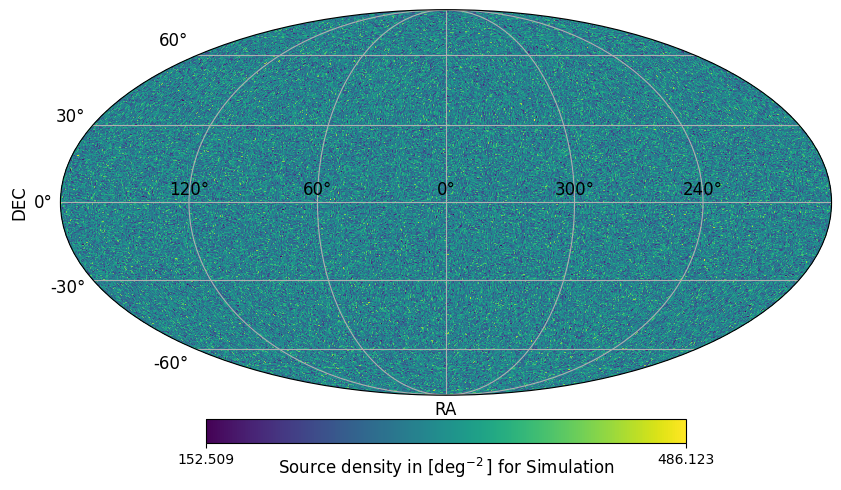

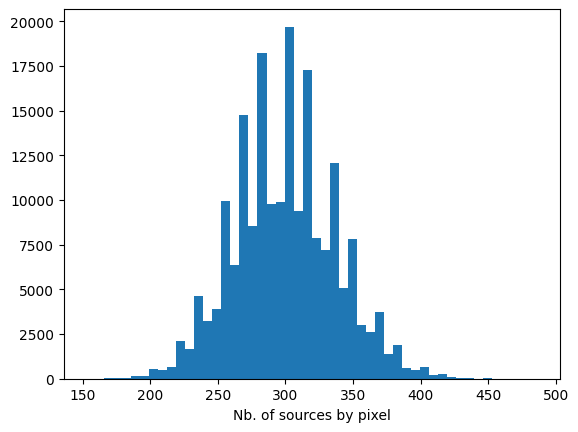

In [7]:
NSource_px_th = int(ALL_Mapper.map.max() * ALL_Mapper.area_deg2)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

#data = generate_lumMag(NSource_px_th*npix, to_table=True)
data = {}
data["RA"], data["DEC"] = generate_raDec(NSource_px_th*npix)
data = Table(data)

simu_Mapper = DensityMapper(data, nside=nside)
simu_Mapper._set_suffixTextPlot(unit = "Simulation") #to customize the unit of plots.
simu_Mapper.plot('')

get_hist(simu_Mapper.map, bins=50);

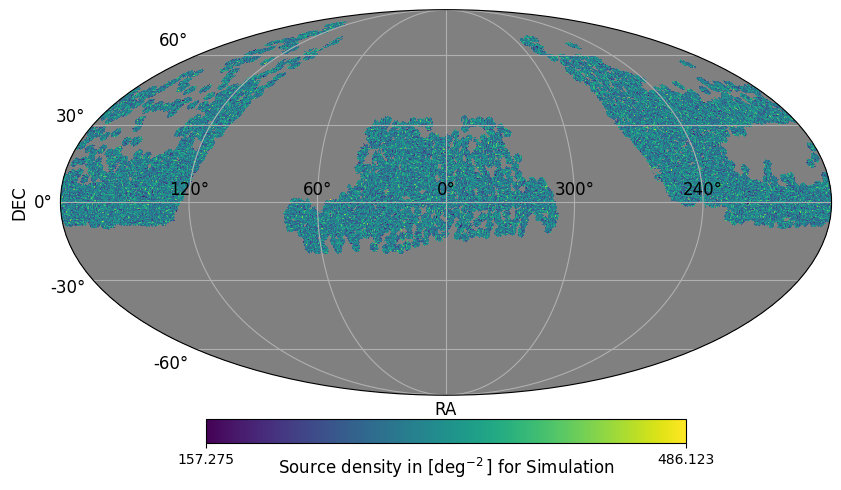

In [8]:
simu_Mapper.set_mask(mask=ALL_Mapper.mapMasked.mask)
simu_Mapper.plot('Masked')

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.328e+05 (χ²/ndof = 1.2)  │              Nfcn = 882              │
│ EDM = 5.6e-06 (Goal: 0.0002)     │           time = 27.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  295.46   │   0.10    │   -0.10    │    0.10    │    0    │         │       │
│ 1 │ A    │  1.9e-3   │  0.4e-3   │  -0.4e-3   │   0.5e-3   │    0    │    1    │       │
│ 2 │ ra   │    154    │    15     │    -14     │     15     │    0    │   360   │       │
│ 3 │ dec  │    15     │    27     │    -28     │     25     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.1    │    0.1    │  -0.4e-3  │  0.5e-3   │    -14    │    15     │    -28    │    25     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │           M           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│   M │      0.0104   -13.65e-6       0.163      -1.778 │
│   A │   -13.65e-6    1.91e-07 -2.15639e-3  3.97901e-3 │
│  ra │       0.163 -2.15639e-3         214     -0.09e3 │
│ dec │      -1.778  3.97901e-3     -0.09e3         770 │
└─────┴─────────────────────────────────────────────────┘

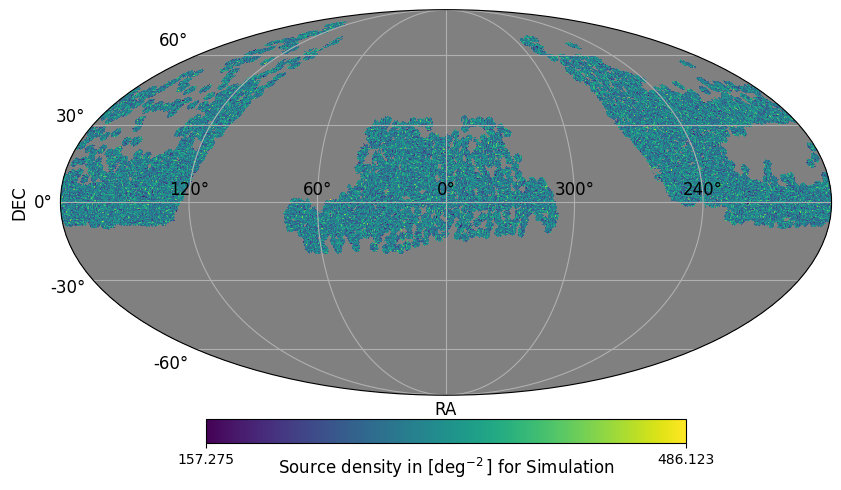

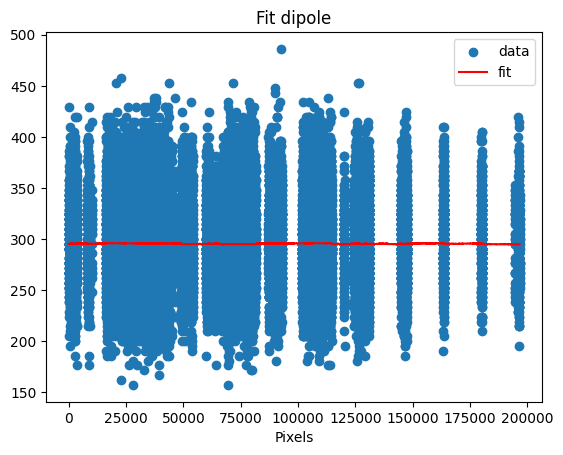

In [9]:
init =  (100, 0, 100, 40)
m = simu_Mapper.fit_dipole("Masked", init)
m

### FRACCOV rescaling

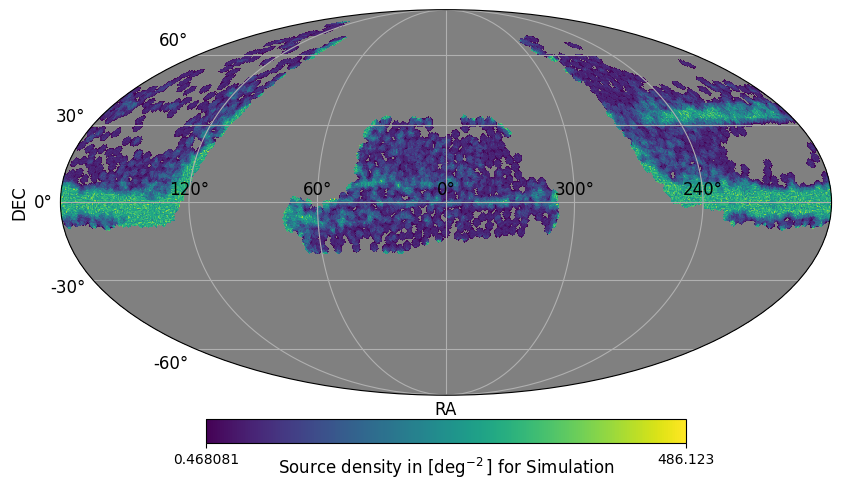

In [10]:
hpmap = simu_Mapper.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_scale = DensityMapper(data=None, nside=nside, hpmap=hpmap)
simu_Mapper_scale._set_suffixTextPlot(unit = "Simulation") #to customize the unit of plots.
simu_Mapper_scale.set_mask()
simu_Mapper_scale.plot('Masked')

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.189e+06 (χ²/ndof = 21.3) │              Nfcn = 429              │
│ EDM = 1.66e-05 (Goal: 0.0002)    │           time = 12.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │   48.08   │   0.04    │   -0.04    │    0.04    │    0    │         │       │
│ 1 │ A    │  0.8312   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  195.01   │   0.22    │   -0.22    │    0.22    │    0    │   360   │       │
│ 3 │ dec  │  -69.07   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.04   │   0.04    │  -0.0014  │  0.0014   │   -0.22   │   0.22    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │        M        A       ra      dec │
├─────┼─────────────────────────────────────┤
│   M │  0.00156  27.7e-6  -0.0004  -0.0005 │
│   A │  27.7e-6 2.07e-06   5.8e-6 -12.4e-6 │
│  ra │  -0.0004   5.8e-6   0.0467   0.0028 │
│ dec │  -0.0005 -12.4e-6   0.0028  0.00291 │
└─────┴─────────────────────────────────────┘

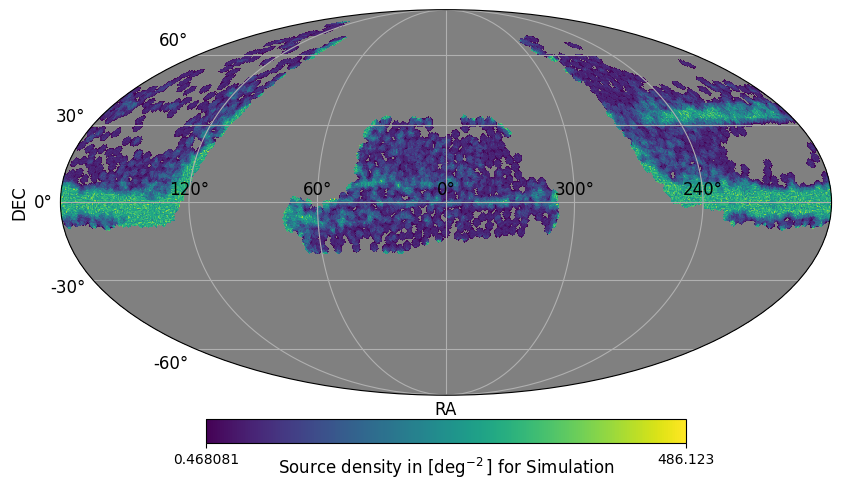

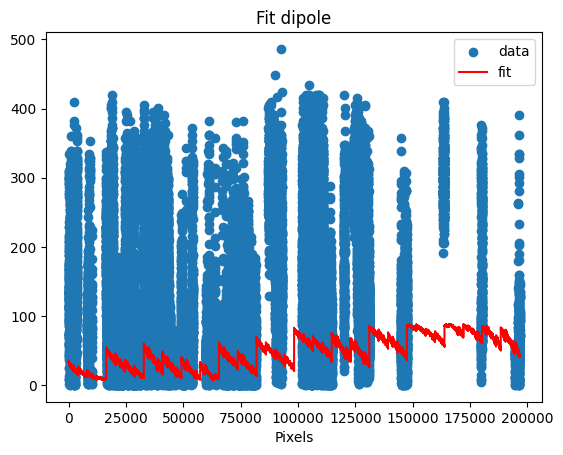

In [11]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.169e+06 (χ²/ndof = 5.9)  │              Nfcn = 368              │
│ EDM = 1.9e-05 (Goal: 0.0002)     │           time = 10.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  146.59   │   0.10    │   -0.10    │    0.10    │    0    │         │       │
│ 1 │ A    │  0.8792   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  185.22   │   0.15    │   -0.15    │    0.15    │    0    │   360   │       │
│ 3 │ dec  │  -65.89   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.1    │    0.1    │  -0.0014  │  0.0014   │   -0.15   │   0.15    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │        M        A       ra      dec │
├─────┼─────────────────────────────────────┤
│   M │   0.0099  46.7e-6    0.001  -0.0025 │
│   A │  46.7e-6 2.02e-06  28.0e-6 -33.9e-6 │
│  ra │    0.001  28.0e-6    0.023  -0.0011 │
│ dec │  -0.0025 -33.9e-6  -0.0011  0.00312 │
└─────┴─────────────────────────────────────┘

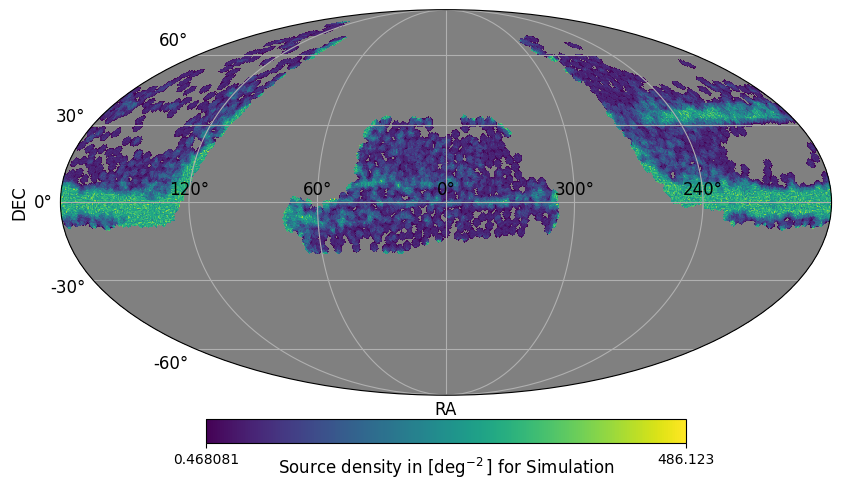

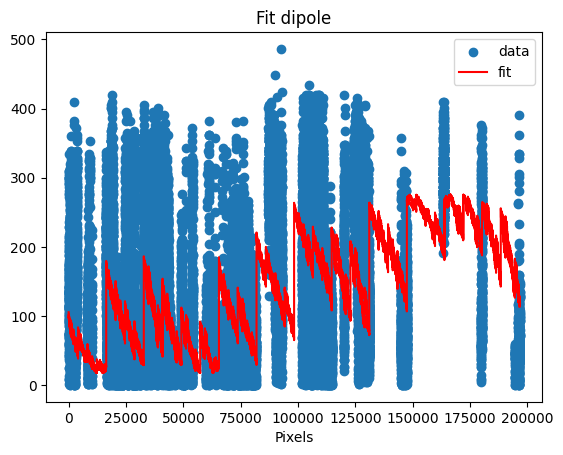

In [12]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

## FRACCOV cut

### From QSO

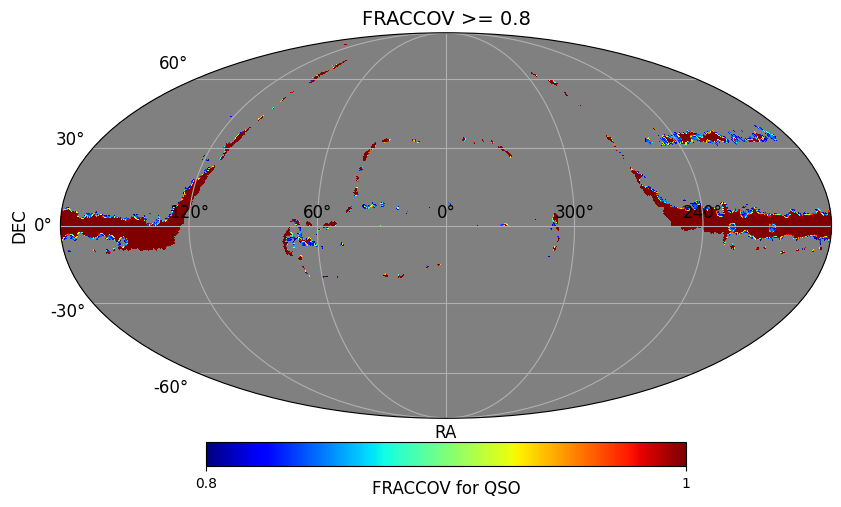

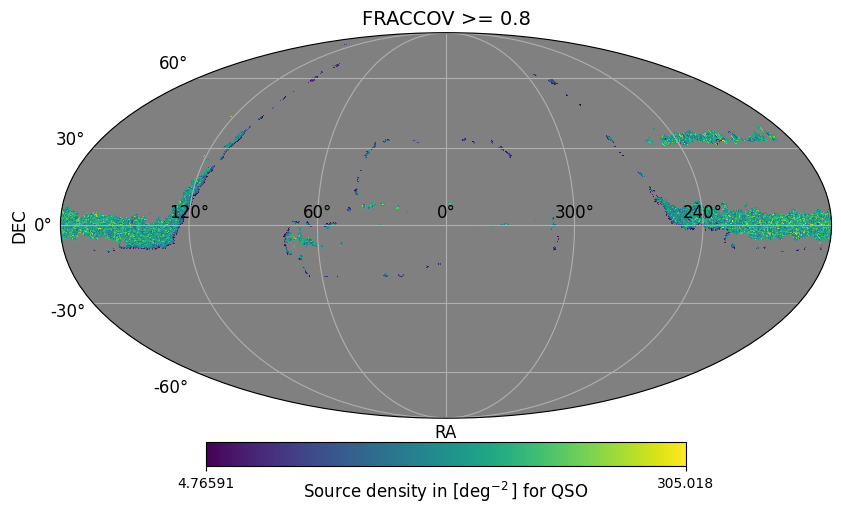

In [13]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'

DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title=title)

ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask)
ALL_Mapper.plot(use_map='Cut', title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.933e+05 (χ²/ndof = 2.0)  │              Nfcn = 877              │
│ EDM = 0.000498 (Goal: 0.0002)    │           time = 27.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  121.10   │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 1 │ A    │  0.4507   │  0.0015   │  -0.0015   │   0.0015   │    0    │    1    │       │
│ 2 │ ra   │   0.004   │  180.354  │   -0.004   │  180.354   │    0    │   360   │       │
│ 3 │ dec  │-89.9999999977│0.0324589096│-0.0000000023│0.0324589096│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │  -0.0015  │  0.0015   │  -0.004   │  180.354  │  -2.3e-9  │32458909.6e-9│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │               M               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│   M │         0.00293          4.8e-6          0.0676         0.20e-9 │
│   A │          4.8e-6        2.19e-06      -8.6781e-3        -0.03e-9 │
│  ra │          0.0676      -8.6781e-3        3.41e+07 100.85124782e-3 │
│ dec │         0.20e-9        -0.03e-9 100.85124782e-3        2.99e-10 │
└─────┴─────────────────────────────────────────────────────────────────┘

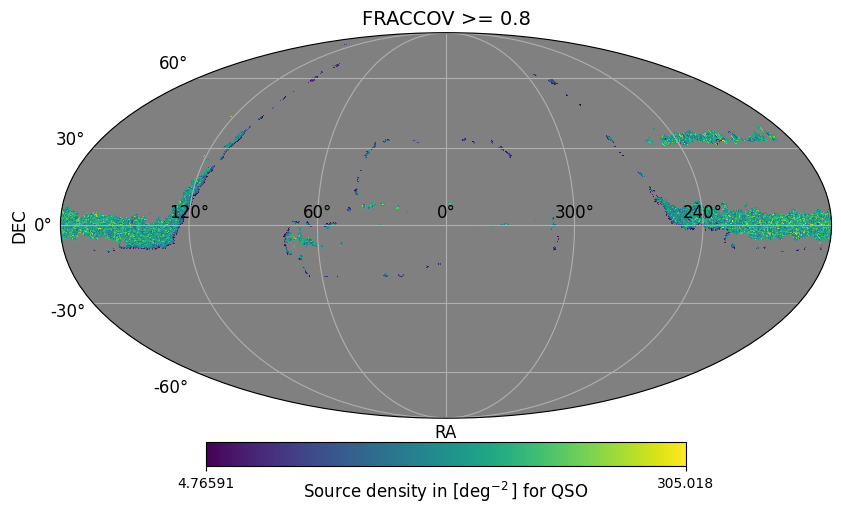

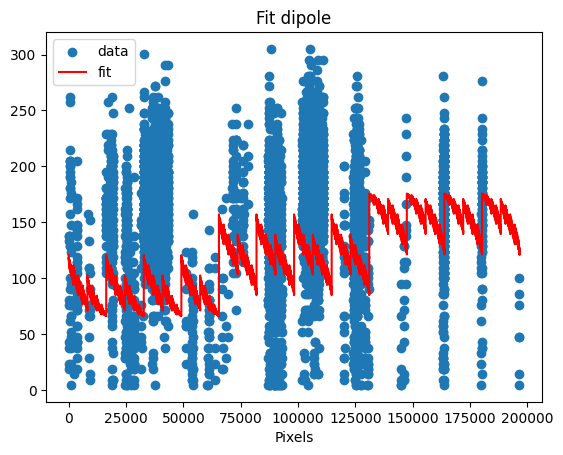

In [14]:
init =  (200, 0, 100, 40)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.


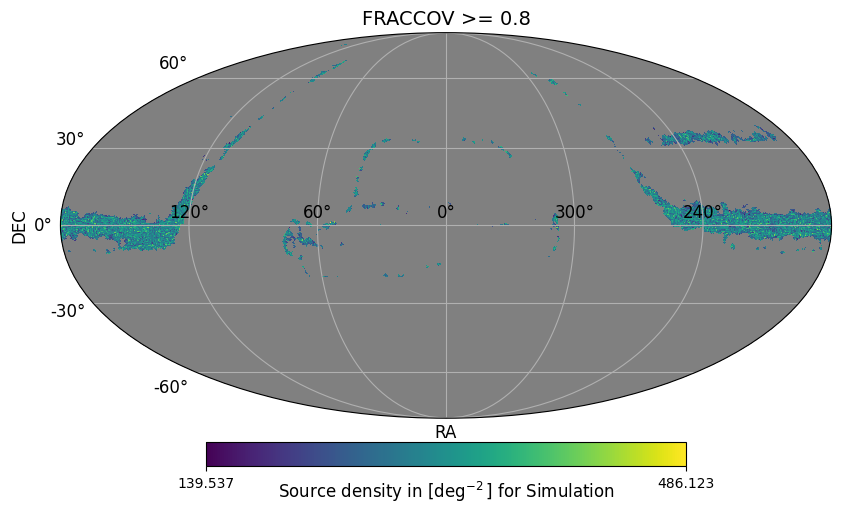

In [15]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'
DR1_Mapper.cut_FracCov(frac_min=frac_min)

simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask)
simu_Mapper_scale.plot(use_map='Cut', title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.436e+04 (χ²/ndof = 0.3)  │              Nfcn = 611              │
│ EDM = 3.39e-05 (Goal: 0.0002)    │           time = 19.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  285.74   │   0.18    │   -0.18    │    0.18    │    0    │         │       │
│ 1 │ A    │  1.0e-9   │66377.1e-9 │  -1.0e-9   │ 66377.1e-9 │    0    │    1    │       │
│ 2 │ ra   │  0.11e3   │  0.30e3   │  -0.11e3   │   0.25e3   │    0    │   360   │       │
│ 3 │ dec  │    83     │    165    │    -165    │     7      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.18   │   0.18    │  -1.0e-9  │66377.1e-9 │  -0.11e3  │  0.25e3   │   -165    │     7     │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │              M              A             ra            dec │
├─────┼─────────────────────────────────────────────────────────────┤
│   M │         0.0312      17.68e-12         -0.000          0.000 │
│   A │      17.68e-12       2.58e-13 -1.32724592e-6   519.11928e-9 │
│  ra │         -0.000 -1.32724592e-6       1.11e+05           -0e3 │
│ dec │          0.000   519.11928e-9           -0e3       4.94e+03 │
└─────┴─────────────────────────────────────────────────────────────┘

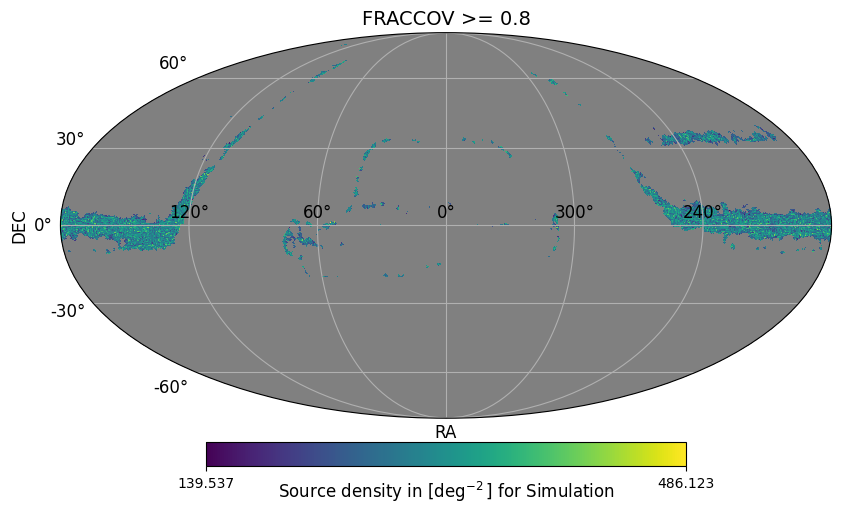

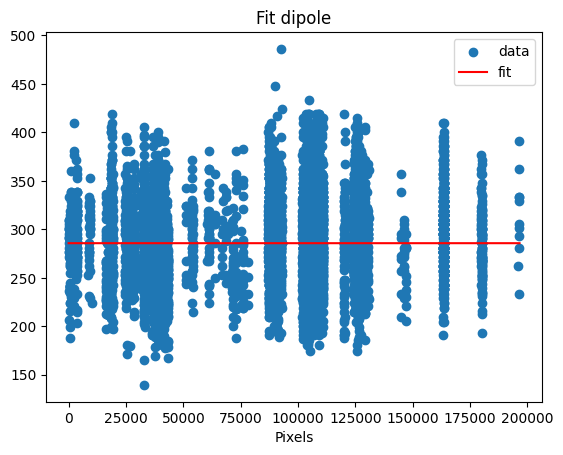

In [16]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Density count > min and FRACCOV > 0.9

### From QSO

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


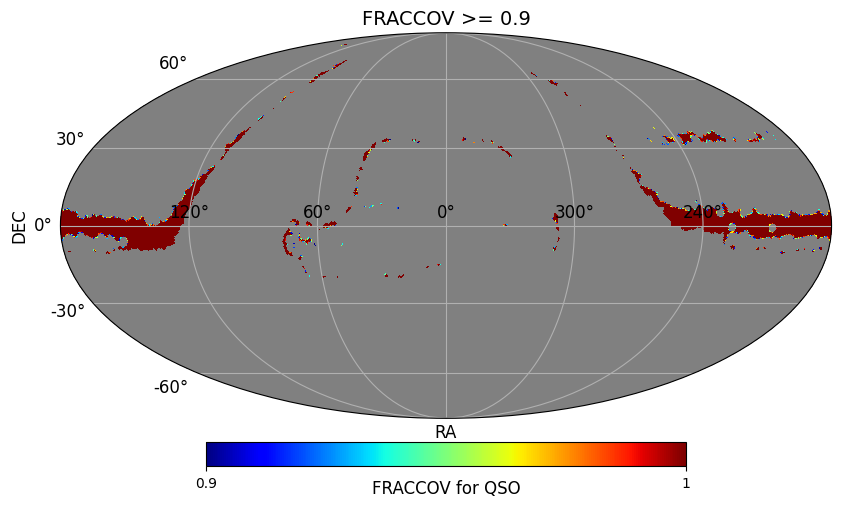

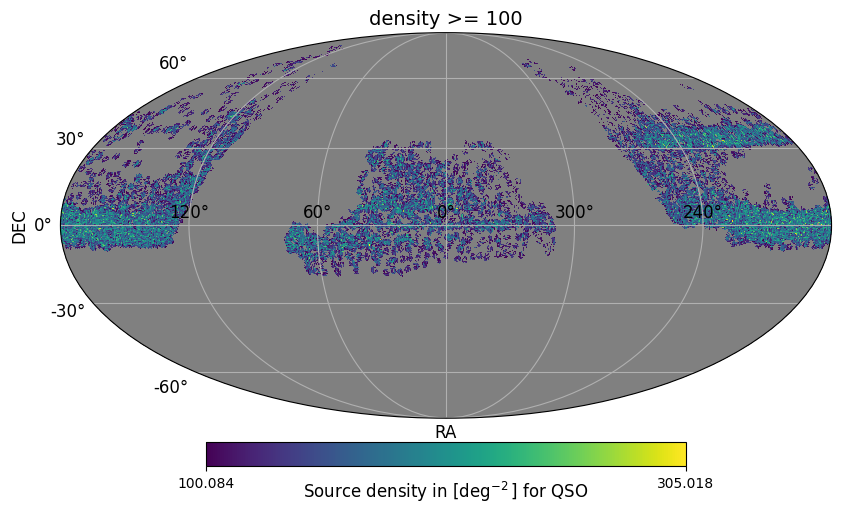

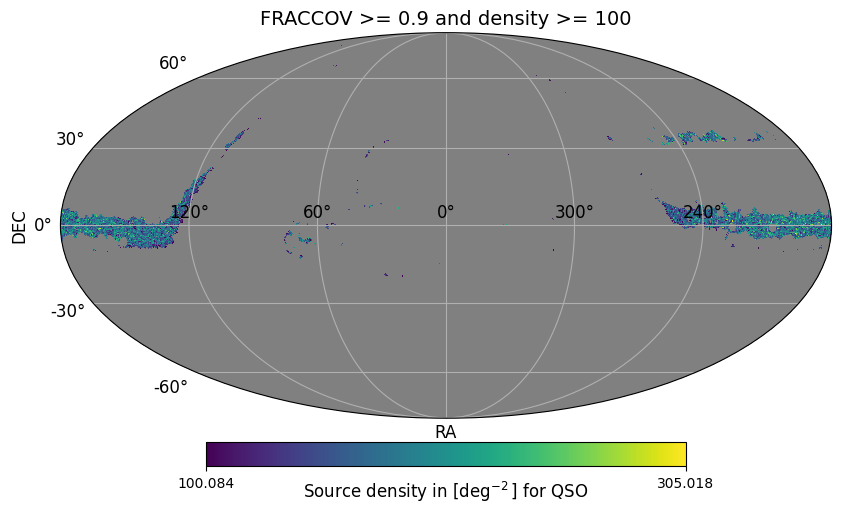

In [17]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
ALL_Mapper.select_bounds(map_min=count_min)
ALL_Mapper.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
ALL_Mapper.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.263e+04 (χ²/ndof = 0.2)  │              Nfcn = 865              │
│ EDM = 3.52e-05 (Goal: 0.0002)    │           time = 26.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  166.44   │   0.16    │   -0.16    │    0.16    │    0    │         │       │
│ 1 │ A    │  1.6e-9   │54139.6e-9 │  -1.6e-9   │ 54139.6e-9 │    0    │    1    │       │
│ 2 │ ra   │  0.01e3   │  0.33e3   │  -0.33e3   │   0.33e3   │    0    │   360   │       │
│ 3 │ dec  │    -50    │    90     │    -90     │     90     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.16   │   0.16    │  -1.6e-9  │54139.6e-9 │  -0.33e3  │  0.33e3   │    -90    │    90     │
│  Valid   │   False   │   False   │   True    │   False   │   False   │   False   │   False   │   False   │
│ At Limit │   False   │   False   │   True    │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   True    │   True    │   True    │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │              M              A             ra            dec │
├─────┼─────────────────────────────────────────────────────────────┤
│   M │         0.0265      78.42e-12         -0.000         -0.001 │
│   A │      78.42e-12       3.45e-13  -157.24934e-9 -4.37005674e-6 │
│  ra │         -0.000  -157.24934e-9       1.15e+04              0 │
│ dec │         -0.001 -4.37005674e-6              0       2.26e+04 │
└─────┴─────────────────────────────────────────────────────────────┘

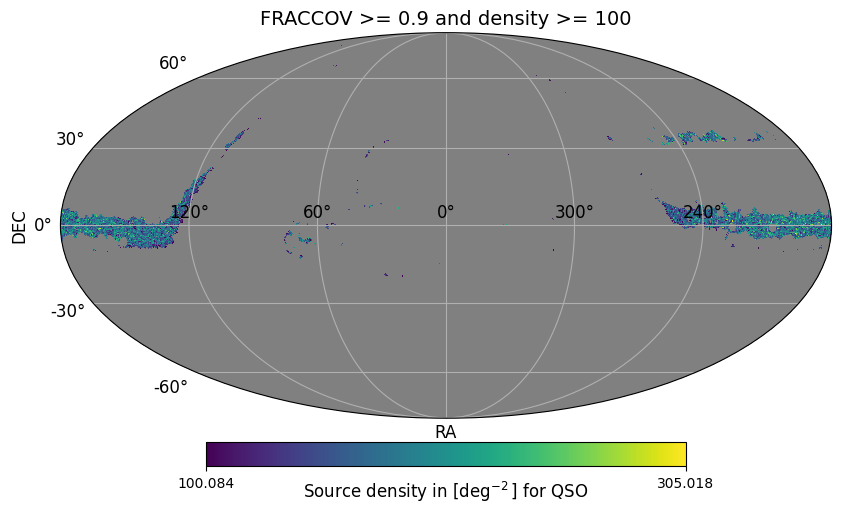

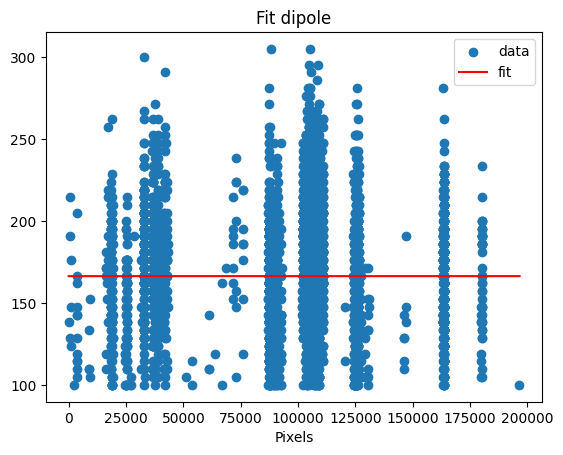

In [18]:
init =  (200, 0, 100, 40)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


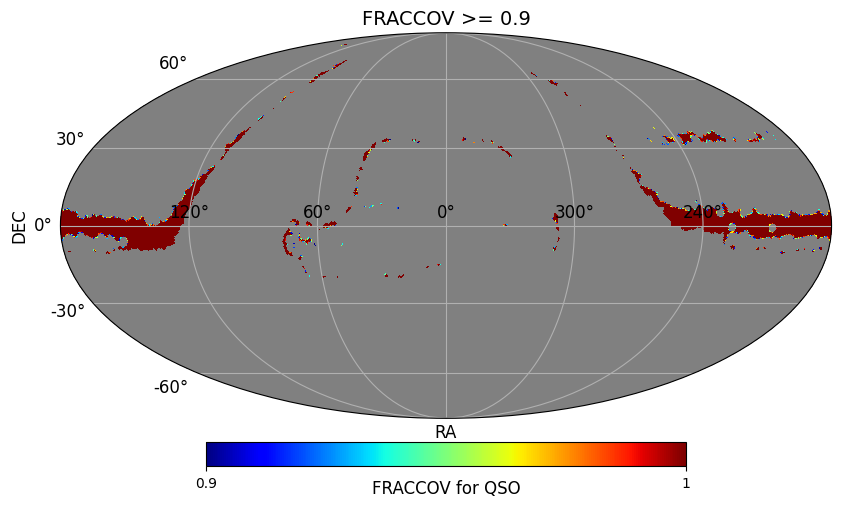

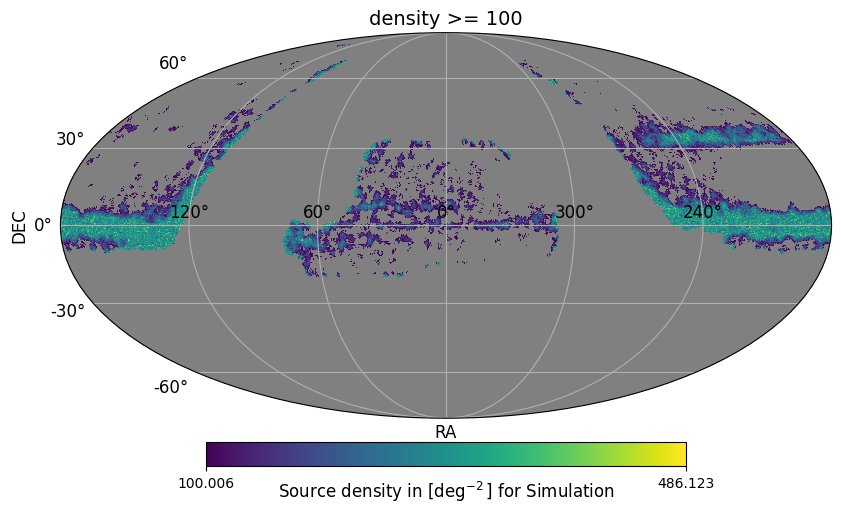

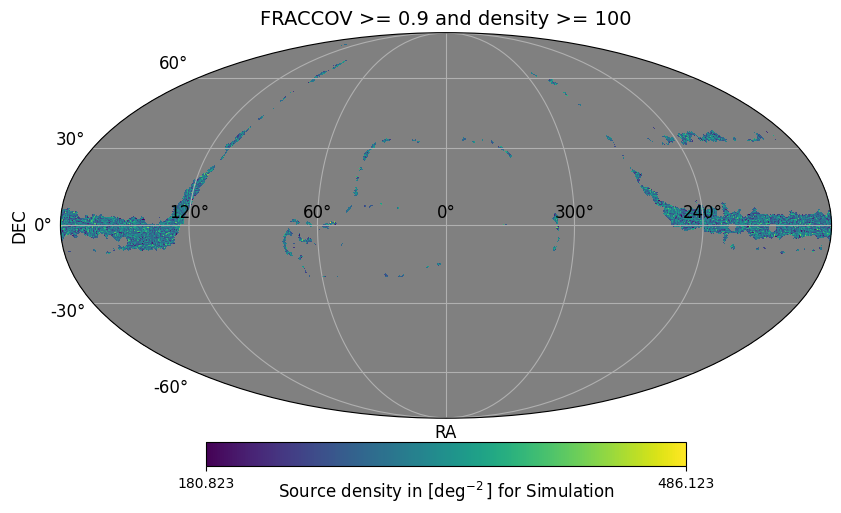

In [19]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
simu_Mapper_scale.select_bounds(map_min=count_min)
simu_Mapper_scale.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
simu_Mapper_scale.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.751e+04 (χ²/ndof = 0.2)  │              Nfcn = 700              │
│ EDM = 4.46e-05 (Goal: 0.0002)    │           time = 21.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  294.63   │   0.12    │   -0.12    │    0.12    │    0    │         │       │
│ 1 │ A    │  1.7e-9   │2698434.6e-9│  -1.7e-9   │2698434.6e-9│    0    │    1    │       │
│ 2 │ ra   │   359.0   │   185.7   │   -185.7   │    1.0     │    0    │   360   │       │
│ 3 │ dec  │  89.968   │  161.477  │  -161.477  │   0.032    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.12   │   0.12    │  -1.7e-9  │2698434.6e-9│  -185.7   │    1.0    │ -161.477  │   0.032   │
│  Valid   │   False   │   False   │   True    │   False   │   False   │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   False   │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   True    │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────────┐
│     │                M                A               ra              dec │
├─────┼─────────────────────────────────────────────────────────────────────┤
│   M │           0.0135        -1.024e-9          518.711            2.793 │
│   A │        -1.024e-9         1.85e-11  -9.245081052977 -49.783571639e-3 │
│  ra │          518.711  -9.245081052977         4.87e+12          26.14e9 │
│ dec │            2.793 -49.783571639e-3          26.14e9         1.41e+08 │
└─────┴─────────────────────────────────────────────────────────────────────┘

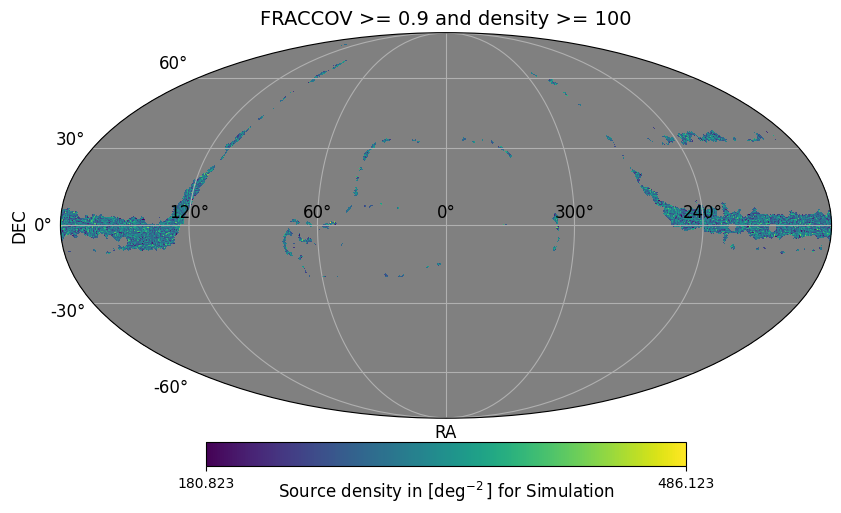

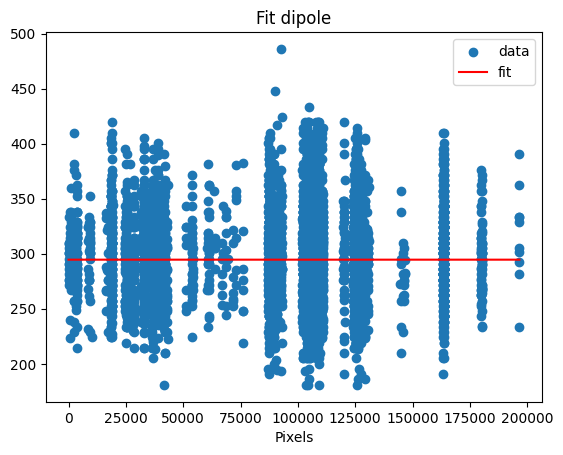

In [20]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m